# 🚀 Hold-Out Strategy with Offline Augmentation & 3-Model Ensemble
#### Document Classification: 5 Groups → 17 Classes
#### k-fold to hold_out
#### Models: EfficientNet-B4 (30%) + ViT (40%) + ConvNeXt (30%)


In [6]:
# Core Libraries
import os
import cv2
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_base
import timm
from efficientnet_pytorch import EfficientNet

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Visualization
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
print("🎯 Complete Setting Environment")

✅ Device: cuda
✅ CUDA Available: True
✅ GPU: NVIDIA GeForce RTX 3090
🎯 Complete Setting Environment


In [7]:
# ============================
# 폰트 설정 (이모티콘 + 한글 지원)
# ============================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 이모티콘 지원을 위한 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 한글 지원 (선택사항 - 한글 라벨이 있을 경우)
try:
    # Linux/Colab 환경
    if os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'):
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()
        print("✅ 한글 폰트 적용: NanumGothic")
    else:
        print("ℹ️ 한글 폰트 없음 (영문만 사용)")
except:
    print("ℹ️ 기본 폰트 사용")

# 이모티콘이 안 보일 경우 폴백
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']

print("✅ 폰트 설정 완료 (이모티콘 지원)")


✅ 한글 폰트 적용: NanumGothic
✅ 폰트 설정 완료 (이모티콘 지원)


In [8]:
# Semantic Grouping 

class_group_mapping = {
    'account_number': 'other',
    'application_for_payment_of_pregnancy_medical_expenses': 'medical',
    'car_dashboard': 'vehicle',
    'confirmation_of_admission_and_discharge': 'medical',
    'confirmation_of_enrollment': 'document',
    'copy_of_bankbook': 'other',
    'copy_of_contract': 'document',
    'drivers_lisense': 'identification',
    'medical_certificate': 'medical',
    'medical_expense_receipt': 'medical',
    'national_id_card': 'identification',
    'passport': 'identification',
    'prescription': 'medical',
    'resume': 'document',
    'statement_of_opinion': 'document',
    'vehicle_registration_certificate': 'vehicle',
    'vehicle_registration_plate': 'vehicle',
}

group_to_idx = {
    'identification': 0,
    'medical': 1,
    'vehicle': 2,
    'document': 3,
    'other': 4
}

# 클래스 이름 (기존 코드)
class_names = [
    'account_number',
    'application_for_payment_of_pregnancy_medical_expenses',
    'car_dashboard',
    'confirmation_of_admission_and_discharge',
    'confirmation_of_enrollment',
    'copy_of_bankbook',
    'copy_of_contract',
    'drivers_lisense',
    'medical_certificate',
    'medical_expense_receipt',
    'national_id_card',
    'passport',
    'prescription',
    'resume',
    'statement_of_opinion',
    'vehicle_registration_certificate',
    'vehicle_registration_plate',
]

print(f"✅ 클래스 개수: {len(class_names)}")
print(f"✅ 그룹 개수: {len(group_to_idx)}")

✅ 클래스 개수: 17
✅ 그룹 개수: 5


In [3]:
print("="*80)
print("🚀 Section 1: Offline Augmentation with Enhanced Transforms")
print("="*80)

# 1-1. 데이터 로드 및 Semantic Grouping
df = pd.read_csv("train.csv")

# Semantic Grouping 적용
df['class_name'] = df['target'].map(lambda x: class_names[x])
df['group'] = df['class_name'].map(class_group_mapping)
df['group_idx'] = df['group'].map(group_to_idx)

print(f"\n✅ Semantic Grouping 완료!")
print(f"   전체 데이터: {len(df)}개")
print(f"\n📊 그룹별 분포:")
print(df['group'].value_counts())

# 1-2. Stratified Split (80:20)
train_df, holdout_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

train_df = train_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

print(f"\n✅ Hold-Out 분리 완료!")
print(f"   학습 데이터: {len(train_df)}개 (80%)")
print(f"   검증 데이터: {len(holdout_df)}개 (20%)")


# 1-3. 클래스별 세분화 증강 파이프라인 (크롭 포함)
print("\n" + "="*80)
print("클래스별 세분화 증강 파이프라인 정의")
print("="*80)

class_augments = {
    # 📄 문서류 (강한 회전 + 90도 + 반전 + 노이즈 + 명암 + 크롭)
    3: A.Compose([
        A.OneOf([
            A.Rotate(limit=30, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.RandomCrop(height=int(224*0.8), width=int(224*0.8), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3)
    ]),
    4: A.Compose([
        A.OneOf([
            A.Rotate(limit=30, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.RandomCrop(height=int(224*0.8), width=int(224*0.8), p=0.3),
    ]),
    12: A.Compose([
        A.OneOf([
            A.Rotate(limit=30, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.RandomCrop(height=int(224*0.8), width=int(224*0.8), p=0.3),
    ]),
    13: A.Compose([
        A.OneOf([
            A.Rotate(limit=30, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.5),
        A.RandomCrop(height=int(224*0.8), width=int(224*0.8), p=0.3),
    ]),
    14: A.Compose([
        A.OneOf([
            A.Rotate(limit=30, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.RandomCrop(height=int(224*0.8), width=int(224*0.8), p=0.3),
    ]),
    
    # 💳 카드/신분증 (90도 추가!)
    7: A.Compose([
        A.OneOf([
            A.Rotate(limit=15, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3)
    ]),
    10: A.Compose([
        A.OneOf([
            A.Rotate(limit=15, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    11: A.Compose([
        A.OneOf([
            A.Rotate(limit=15, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    15: A.Compose([
        A.OneOf([
            A.Rotate(limit=15, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    
    # 🚗 차량/대시보드 (90도 추가!)
    2: A.Compose([
        A.OneOf([
            A.Rotate(limit=10, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
        ], p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    ]),
    16: A.Compose([
        A.OneOf([
            A.Rotate(limit=10, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
        ], p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    ]),
    
    # 📋 증명서/영수증
    8: A.Compose([
        A.OneOf([
            A.Rotate(limit=20, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    9: A.Compose([
        A.OneOf([
            A.Rotate(limit=20, p=1.0),
            A.Rotate(limit=90, p=1.0),
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.GaussNoise(p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    
    # 🏦 은행/계약 (90도 추가!)
    0: A.Compose([
        A.OneOf([
            A.Rotate(limit=25, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    5: A.Compose([
        A.OneOf([
            A.Rotate(limit=25, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    6: A.Compose([
        A.OneOf([
            A.Rotate(limit=25, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
        A.RandomCrop(height=int(224*0.85), width=int(224*0.85), p=0.2),
    ]),
    
    # 기타 (90도 추가!)
    1: A.Compose([
        A.OneOf([
            A.Rotate(limit=20, p=1.0),
            A.Rotate(limit=90, p=1.0),  # ← 90도 추가!
            A.HorizontalFlip(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    ]),
}

print(f"\n✅ 클래스별 증강 파이프라인 준비 완료!")
print(f"   0~16: 총 17개 클래스 증강 정의됨")
print(f"   - 문서류(3,4,12,13,14): 회전(±30°/90°) + 좌우반전 + 노이즈 + 명암 + 크롭")
print(f"   - 카드류(7,10,11,15): 회전(±15°/90°) + 좌우반전 + 명암 + 크롭")
print(f"   - 차량(2,16): 회전(±10°/90°) + 명암")
print(f"   - 증명서(8,9): 회전(±20°/90°) + 좌우반전 + 노이즈 + 명암 + 크롭")
print(f"   - 은행(0,5,6): 회전(±25°/90°) + 좌우반전 + 명암 + 크롭")
print(f"   - 기타(1): 회전(±20°/90°) + 좌우반전 + 명암")


# 1-4. 오프라인 증강 실행 (클래스별)
print(f"\n" + "="*80)
print(f"🔄 오프라인 증강 실행 (클래스별 세분화)...")
print(f"="*80)

input_dir = "train"
output_dir = "train_aug"
os.makedirs(output_dir, exist_ok=True)

aug_data = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Augmenting"):
    img_name = row['ID']
    label = row['target']
    img_path = os.path.join(input_dir, img_name)
    
    image = cv2.imread(img_path)
    if image is None:
        continue
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 원본 저장
    cv2.imwrite(
        os.path.join(output_dir, img_name),
        cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    )
    aug_data.append({
        "ID": img_name,
        "target": label,
        "class_name": row['class_name'],
        "group": row['group'],
        "group_idx": row['group_idx']
    })

    # 클래스별 증강 적용 (4개 이미지 생성)
    augment = class_augments.get(label)
    
    if augment:
        for i in range(4):
            try:
                augmented = augment(image=image)["image"]
                new_name = f"{os.path.splitext(img_name)[0]}_aug{i+1}.jpg"
                cv2.imwrite(
                    os.path.join(output_dir, new_name),
                    cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
                )
                aug_data.append({
                    "ID": new_name,
                    "target": label,
                    "class_name": row['class_name'],
                    "group": row['group'],
                    "group_idx": row['group_idx']
                })
            except Exception as e:
                print(f"⚠️ Error augmenting {img_name}: {e}")
                pass

aug_df = pd.DataFrame(aug_data)
aug_df.to_csv("aug_train.csv", index=False)

print(f"\n✅ 클래스별 세분화 증강 완료!")
print(f"   총 {len(aug_df)}개 이미지")
print(f"   - 원본: {len(train_df)}개")
print(f"   - 증강: {len(aug_df) - len(train_df)}개")

# 증강 CSV 저장
aug_df = pd.DataFrame(aug_data)
aug_df.to_csv("train_aug.csv", index=False)

print(f"\n✅ 오프라인 증강 완료!")
print(f"   원본: {len(train_df)}개")
print(f"   증강 후: {len(aug_df)}개")
print(f"   증강 배율: {len(aug_df) / len(train_df):.1f}x")


🚀 Section 1: Offline Augmentation with Enhanced Transforms

✅ Semantic Grouping 완료!
   전체 데이터: 1570개

📊 그룹별 분포:
group
medical           446
document          324
vehicle           300
identification    300
other             200
Name: count, dtype: int64

✅ Hold-Out 분리 완료!
   학습 데이터: 1256개 (80%)
   검증 데이터: 314개 (20%)

클래스별 세분화 증강 파이프라인 정의

✅ 클래스별 증강 파이프라인 준비 완료!
   0~16: 총 17개 클래스 증강 정의됨
   - 문서류(3,4,12,13,14): 회전(±30°/90°) + 좌우반전 + 노이즈 + 명암 + 크롭
   - 카드류(7,10,11,15): 회전(±15°/90°) + 좌우반전 + 명암 + 크롭
   - 차량(2,16): 회전(±10°/90°) + 명암
   - 증명서(8,9): 회전(±20°/90°) + 좌우반전 + 노이즈 + 명암 + 크롭
   - 은행(0,5,6): 회전(±25°/90°) + 좌우반전 + 명암 + 크롭
   - 기타(1): 회전(±20°/90°) + 좌우반전 + 명암

🔄 오프라인 증강 실행 (클래스별 세분화)...


Augmenting: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1256/1256 [00:46<00:00, 27.06it/s]


✅ 클래스별 세분화 증강 완료!
   총 6280개 이미지
   - 원본: 1256개
   - 증강: 5024개

✅ 오프라인 증강 완료!
   원본: 1256개
   증강 후: 6280개
   증강 배율: 5.0x



📊 증강 샘플 확인 중 (그룹별 랜덤)...


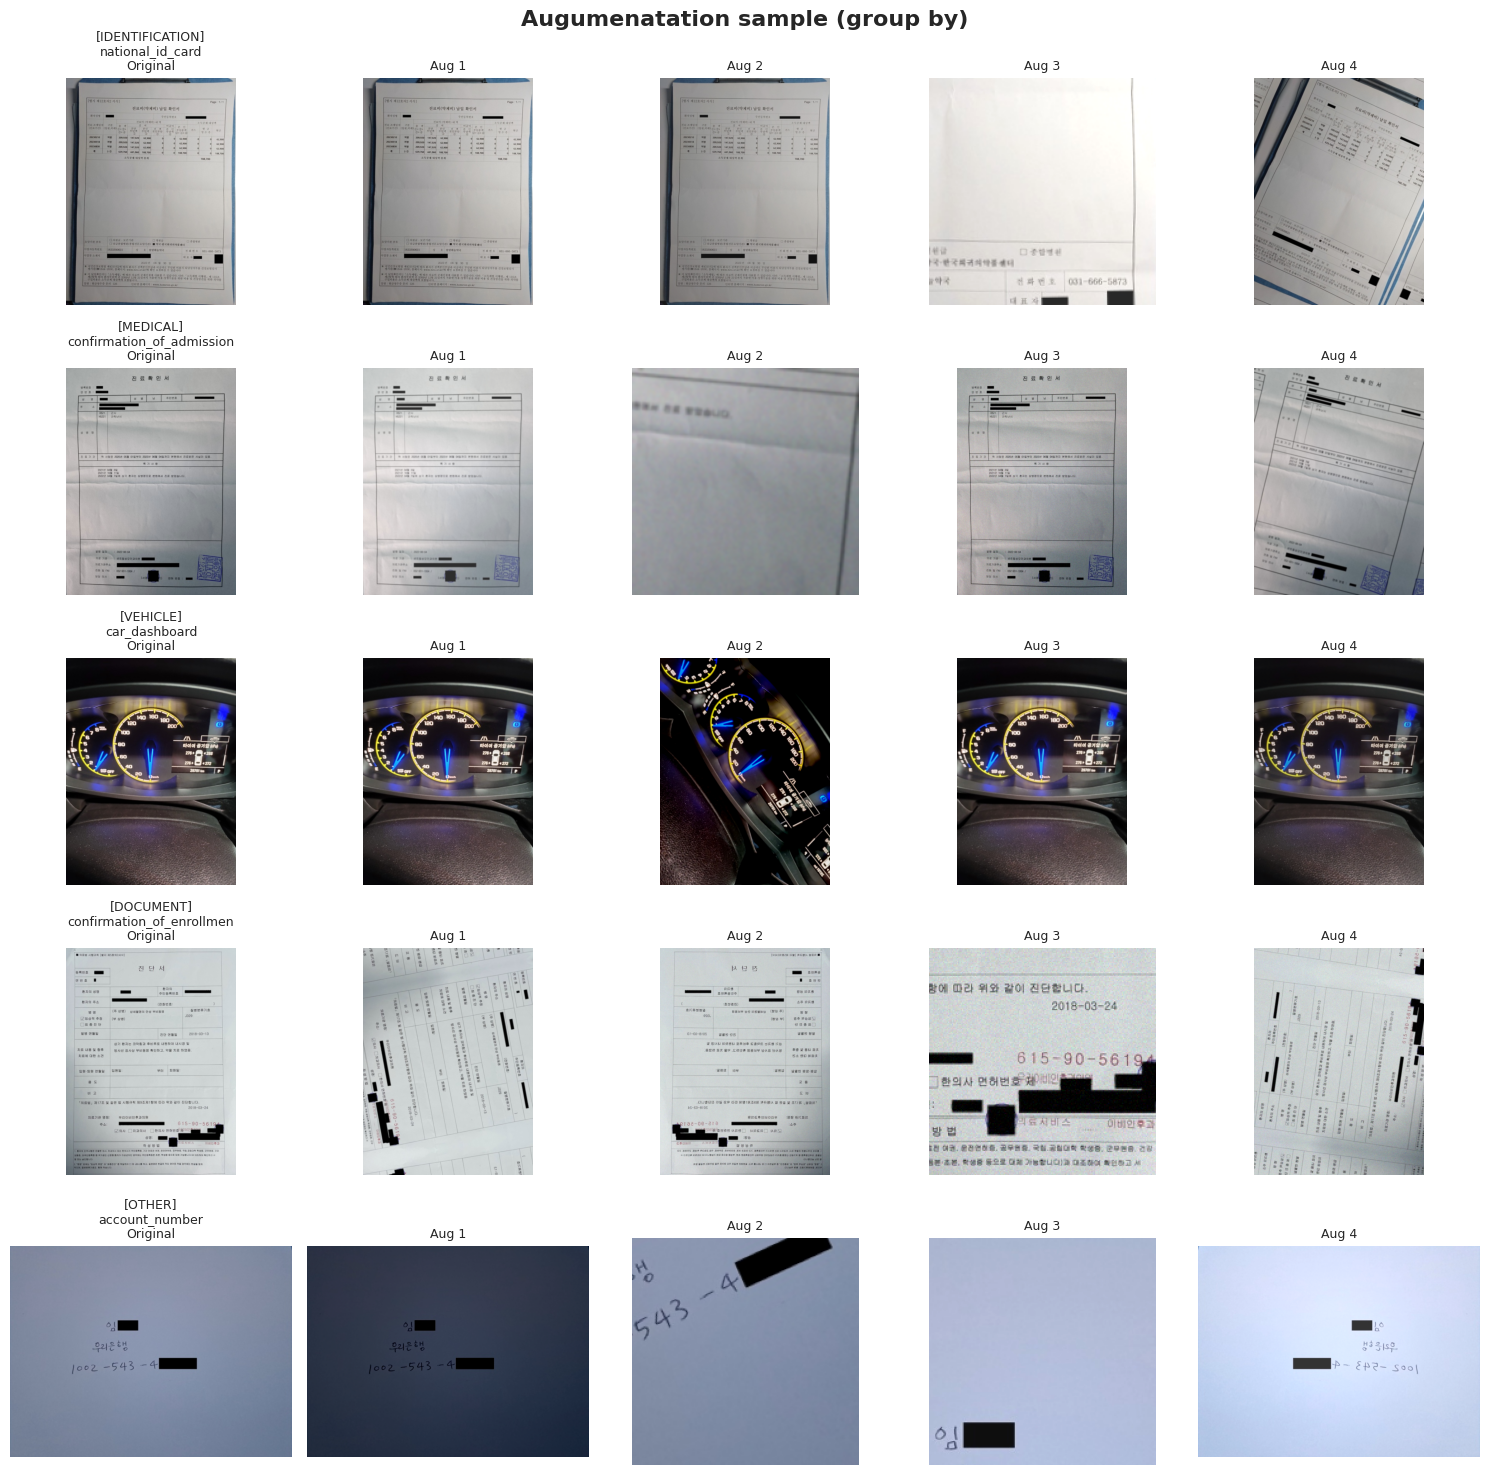

✅ 시각화 완료!

표시된 그룹:
   [identification ] national_id_card (Class 10)
   [medical        ] confirmation_of_admission_and_discharge (Class 3)
   [vehicle        ] car_dashboard (Class 2)
   [document       ] confirmation_of_enrollment (Class 4)
   [other          ] account_number (Class 0)

📊 데이터 증강 통계

원본 학습 데이터: 1256개
증강 후 학습 데이터: 6280개
증강 배율: 5.0x
추가된 이미지: 5024개

검증 데이터 (Hold-Out): 314개 (증강 안함)

전체 데이터:
- 증강된 학습: 6280개
- 원본 검증: 314개
- 총합: 6594개

📊 증강 후 그룹별 분포:
group
document          1295
identification    1200
medical           1785
other              800
vehicle           1200
Name: count, dtype: int64

📊 증강 후 클래스별 분포:
각 클래스는 7배씩 증가됨:
   Class  0 (account_number                          ):   400개
   Class  1 (application_for_payment_of_pregnancy_medical_expenses):   185개
   Class  2 (car_dashboard                           ):   400개
   Class  3 (confirmation_of_admission_and_discharge ):   400개
   Class  4 (confirmation_of_enrollment              ):   400개
   Class  5 (copy_of_bankbo

In [4]:
# 1-5. 증강 샘플 시각화 (클래스별 세분화 반영)
print(f"\n📊 증강 샘플 확인 중 (그룹별 랜덤)...")

selected_samples = {}

for group_name in ['identification', 'medical', 'vehicle', 'document', 'other']:
    group_rows = train_df[train_df['group'] == group_name]
    
    if len(group_rows) > 0:
        # 랜덤 선택
        sample_row = group_rows.sample(n=1).iloc[0]
        img_name = sample_row['ID']
        class_name = sample_row['class_name']
        label = sample_row['target']
        
        img_path = os.path.join(input_dir, img_name)
        image = cv2.imread(img_path)
        
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            selected_samples[group_name] = {
                'img_name': img_name,
                'class_name': class_name,
                'label': label,
                'images': []
            }
            
            # 원본
            selected_samples[group_name]['images'].append({
                'image': image,
                'aug_name': 'Original'
            })
            
            # 클래스별 증강 4개 생성 (시각화용)
            augment = class_augments.get(label)
            if augment:
                for i in range(4):
                    try:
                        augmented = augment(image=image)["image"]
                        selected_samples[group_name]['images'].append({
                            'image': augmented,
                            'aug_name': f'Aug {i+1}'
                        })
                    except:
                        pass

# 시각화
num_groups = len(selected_samples)
num_cols = 5  # 원본 + 증강 4개

fig, axes = plt.subplots(num_groups, num_cols, figsize=(15, num_groups * 3))
fig.suptitle('Augumenatation sample (group by)', fontsize=16, fontweight='bold')

for row_idx, (group_name, data) in enumerate(selected_samples.items()):
    for col_idx, aug_data in enumerate(data['images']):
        if num_groups > 1:
            ax = axes[row_idx, col_idx]
        else:
            ax = axes[col_idx]
        
        ax.imshow(aug_data['image'])
        
        # 제목 설정
        if col_idx == 0:
            title = f"[{group_name.upper()}]\n{data['class_name'][:25]}\n{aug_data['aug_name']}"
        else:
            title = aug_data['aug_name']
        
        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ 시각화 완료!")
print(f"\n표시된 그룹:")
for group_name, data in selected_samples.items():
    print(f"   [{group_name:15s}] {data['class_name']} (Class {data['label']})")

# check augumenatation
print(f"\n" + "="*50)
print(f"📊 데이터 증강 통계")
print(f"="*50)

print(f"\n원본 학습 데이터: {len(train_df)}개")
print(f"증강 후 학습 데이터: {len(aug_df)}개")
print(f"증강 배율: {len(aug_df) / len(train_df):.1f}x")
print(f"추가된 이미지: {len(aug_df) - len(train_df)}개")

print(f"\n검증 데이터 (Hold-Out): {len(holdout_df)}개 (증강 안함)")

print(f"\n전체 데이터:")
print(f"- 증강된 학습: {len(aug_df)}개")
print(f"- 원본 검증: {len(holdout_df)}개")
print(f"- 총합: {len(aug_df) + len(holdout_df)}개")

# 그룹별 분포 확인
print(f"\n📊 증강 후 그룹별 분포:")
print(aug_df['group'].value_counts().sort_index())

# 클래스별 분포 확인
print(f"\n📊 증강 후 클래스별 분포:")
print(f"각 클래스는 7배씩 증가됨:")
for cls in range(len(class_names)):
    count = len(aug_df[aug_df['target'] == cls])
    print(f"   Class {cls:2d} ({class_names[cls]:40s}): {count:5d}개")


In [14]:
print("="*80)
print("🚀 Section 2: EfficientNet-B4 Hold-Out Training")
print("="*80)

# ============================
# 2-1. 모델 클래스 정의 (기존 코드)
# ============================
class HierarchicalDocumentClassifier(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        # B4 Backbone
        self.backbone = EfficientNet.from_pretrained('efficientnet-b4')
        backbone_out = 1792
        
        # Group Head (5개 그룹)
        self.group_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_groups)
        )
        
        # Fine-grained Head (17개 클래스)
        self.fine_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone.extract_features(x)
        features = nn.functional.adaptive_avg_pool2d(features, 1)
        features = features.view(features.size(0), -1)
        
        group_logits = self.group_head(features)
        fine_logits = self.fine_head(features)
        
        return group_logits, fine_logits

# ============================
# 2-2. Dataset 클래스 정의
# ============================
class DocumentDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image=np.array(image))['image']
        
        target = row['target']
        group_idx = row['group_idx']
        
        return {
            'image': image,
            'target': target,
            'group_idx': group_idx
        }

# ============================
# 2-3. Transform 정의
# ============================
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

# 2-4. Dataset 생성
train_dataset = DocumentDataset(aug_df, "train_aug", transform=train_transform)
val_dataset = DocumentDataset(holdout_df, "train", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)

print(f"\n✅ Dataset 생성 완료!")
print(f"   학습 데이터: {len(train_dataset)}개")
print(f"   검증 데이터: {len(val_dataset)}개")
print(f"   배치 크기: 8")

🚀 Section 2: EfficientNet-B4 Hold-Out Training

✅ Dataset 생성 완료!
   학습 데이터: 6280개
   검증 데이터: 314개
   배치 크기: 8


🚀 Section 2: EfficientNet-B4 Hold-Out Training

✅ Dataset 생성 완료!
   학습 데이터: 6280개
   검증 데이터: 314개
   배치 크기: 8
Loaded pretrained weights for efficientnet-b4

✅ 모델 설정 완료!
   Backbone: EfficientNet-B4
   학습률: 1e-4
   배치 크기: 8
   에포크: 30
   Early Stopping Patience: 5

🚀 B4 Hold-Out Training 시작...



[Epoch  1/30] Train Loss: 0.8976 | Val F1: 0.8368 ✅ BEST



[Epoch  2/30] Train Loss: 0.3031 | Val F1: 0.8792 ✅ BEST



[Epoch  3/30] Train Loss: 0.1680 | Val F1: 0.9124 ✅ BEST



[Epoch  4/30] Train Loss: 0.1054 | Val F1: 0.9150 ✅ BEST


...


[Epoch 13/30] Train Loss: 0.0349 | Val F1: 0.9305 (patience 2/5)



[Epoch 14/30] Train Loss: 0.0338 | Val F1: 0.9210 (patience 3/5)



[Epoch 15/30] Train Loss: 0.0147 | Val F1: 0.9305 (patience 4/5)


findfont: Font family 'NanumGothic' not found.                                                                                                                  
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not 


[Epoch 16/30] Train Loss: 0.0335 | Val F1: 0.9089 (patience 5/5)

⏹️ Early Stopping! (Epoch 16)

📊 B4 학습 결과 시각화


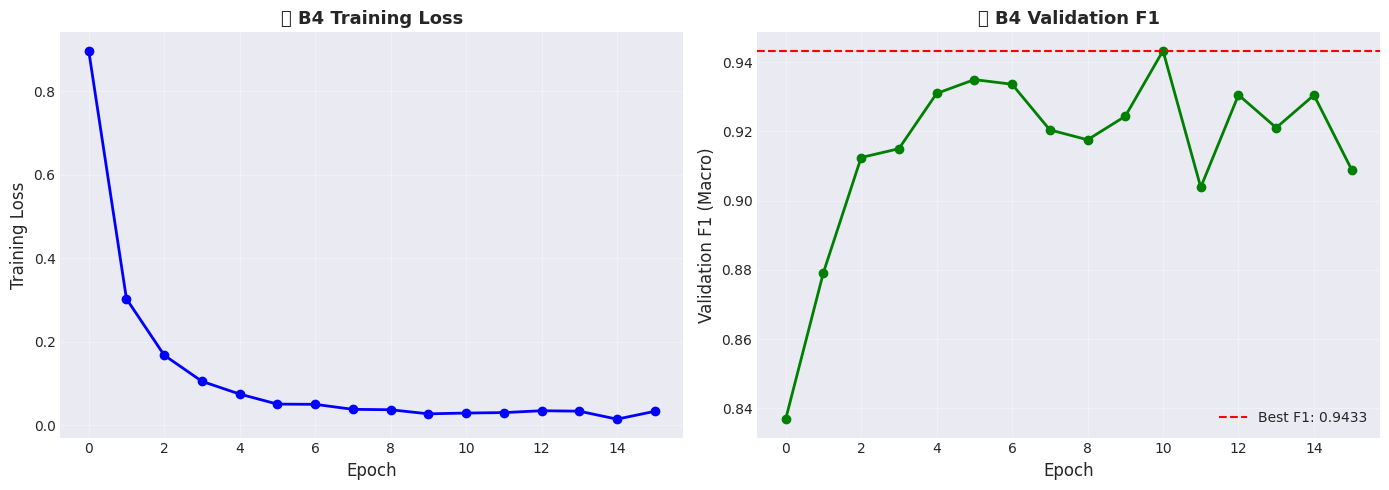


✅ B4 학습 완료!
   최종 Val F1: 0.9433
   총 에포크: 16
   모델 저장: best_fold_b4_model.pth


In [21]:
# 2-5. 모델, 옵티마이저, 손실함수 정의
model_b4 = HierarchicalDocumentClassifier(num_groups=5, num_classes=17).to(DEVICE)

optimizer = optim.AdamW(model_b4.parameters(), lr=1e-4, weight_decay=1e-4)

group_loss_fn = nn.CrossEntropyLoss()
fine_loss_fn = nn.CrossEntropyLoss()

num_epochs = 30
early_stop_patience = 5
best_val_f1 = 0
patience_counter = 0

print(f"\n✅ 모델 설정 완료!")
print(f"   Backbone: EfficientNet-B4")
print(f"   학습률: 1e-4")
print(f"   배치 크기: 8")
print(f"   에포크: {num_epochs}")
print(f"   Early Stopping Patience: {early_stop_patience}")

# 2-6. Hold-Out 학습 루프
print(f"\n" + "="*80)
print(f"🚀 B4 Hold-Out Training 시작...")
print(f"="*80)

train_losses = []
val_f1_scores = []

for epoch in range(num_epochs):
    # -------- Train --------
    model_b4.train()
    train_loss = 0
    
    for batch in tqdm(train_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Train", leave=False):
        images = batch['image'].to(DEVICE)
        targets = batch['target'].to(DEVICE)
        group_targets = batch['group_idx'].to(DEVICE)
        
        optimizer.zero_grad()
        
        group_logits, fine_logits = model_b4(images)
        
        group_loss = group_loss_fn(group_logits, group_targets)
        fine_loss = fine_loss_fn(fine_logits, targets)
        loss = group_loss * 0.3 + fine_loss * 0.7
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # -------- Validation --------
    model_b4.eval()
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Val", leave=False):
            images = batch['image'].to(DEVICE)
            targets = batch['target'].to(DEVICE)
            
            _, fine_logits = model_b4(images)
            preds = fine_logits.argmax(dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())
    
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    val_f1_scores.append(val_f1)
    
    # -------- 결과 출력 --------
    print(f"\n[Epoch {epoch+1:2d}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val F1: {val_f1:.4f}", end="")
    
    # -------- Early Stopping --------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model_b4.state_dict(), "best_fold_b4_model.pth")
        print(" ✅ BEST")
    else:
        patience_counter += 1
        print(f" (patience {patience_counter}/{early_stop_patience})")
        
        if patience_counter >= early_stop_patience:
            print(f"\n⏹️ Early Stopping! (Epoch {epoch+1})")
            break


# 2-7. 학습 결과 시각화
print(f"\n" + "="*80)
print(f"📊 B4 학습 결과 시각화")
print(f"="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
axes[0].plot(train_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('🔵 B4 Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Val F1
axes[1].plot(val_f1_scores, 'g-o', linewidth=2, markersize=6)
axes[1].axhline(y=best_val_f1, color='r', linestyle='--', label=f'Best F1: {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation F1 (Macro)', fontsize=12)
axes[1].set_title('🟢 B4 Validation F1', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ B4 학습 완료!")
print(f"   최종 Val F1: {best_val_f1:.4f}")
print(f"   총 에포크: {len(train_losses)}")
print(f"   모델 저장: best_fold_b4_model.pth")


In [18]:
print("="*80)
print("🚀 Section 3: Vision Transformer (ViT) Hold-Out Training")
print("="*80)


# 3-1. ViT 모델 클래스 정의

class HierarchicalViT(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        # ViT Backbone (timm 라이브러리 사용)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True)
        backbone_out = self.backbone.num_features
        
        # 기존 head 제거
        self.backbone.head = nn.Identity()
        
        # Group Head (5개 그룹)
        self.group_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_groups)
        )
        
        # Fine-grained Head (17개 클래스)
        self.fine_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        
        group_logits = self.group_head(features)
        fine_logits = self.fine_head(features)
        
        return group_logits, fine_logits

print(f"✅ ViT 모델 클래스 정의 완료!")


# 3-2. ViT용 Transform (224x224)

vit_train_transform = A.Compose([
    A.Resize(224, 224),  # ViT는 224x224 사용
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

vit_val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])


# 3-3. ViT Dataset 생성

vit_train_dataset = DocumentDataset(aug_df, "train_aug", transform=vit_train_transform)
vit_val_dataset = DocumentDataset(holdout_df, "train", transform=vit_val_transform)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=8, shuffle=True, num_workers=4)
vit_val_loader = DataLoader(vit_val_dataset, batch_size=8, shuffle=False, num_workers=4)

print(f"\n✅ ViT Dataset 생성 완료!")
print(f"   학습 데이터: {len(vit_train_dataset)}개")
print(f"   검증 데이터: {len(vit_val_dataset)}개")
print(f"   이미지 크기: 224×224")
print(f"   배치 크기: 8")


# 3-4. ViT 모델, 옵티마이저, 손실함수

model_vit = HierarchicalViT(num_groups=5, num_classes=17).to(DEVICE)

vit_optimizer = optim.AdamW(model_vit.parameters(), lr=3e-5, weight_decay=1e-4)

vit_group_loss_fn = nn.CrossEntropyLoss()
vit_fine_loss_fn = nn.CrossEntropyLoss()

vit_num_epochs = 30
vit_early_stop_patience = 5
vit_best_val_f1 = 0
vit_patience_counter = 0

print(f"\n✅ ViT 설정 완료!")
print(f"   Backbone: ViT-Base (Patch 16)")
print(f"   학습률: 3e-5")
print(f"   배치 크기: 8")
print(f"   에포크: {vit_num_epochs}")
print(f"   Early Stopping Patience: {vit_early_stop_patience}")


# 3-5. ViT Hold-Out 학습 루프

print(f"\n" + "="*80)
print(f"🚀 ViT Hold-Out Training 시작...")
print(f"="*80)

vit_train_losses = []
vit_val_f1_scores = []

for epoch in range(vit_num_epochs):
    # -------- Train --------
    model_vit.train()
    train_loss = 0
    
    for batch in tqdm(vit_train_loader, desc=f"[Epoch {epoch+1}/{vit_num_epochs}] Train", leave=False):
        images = batch['image'].to(DEVICE)
        targets = batch['target'].to(DEVICE)
        group_targets = batch['group_idx'].to(DEVICE)
        
        vit_optimizer.zero_grad()
        
        group_logits, fine_logits = model_vit(images)
        
        group_loss = vit_group_loss_fn(group_logits, group_targets)
        fine_loss = vit_fine_loss_fn(fine_logits, targets)
        loss = group_loss * 0.3 + fine_loss * 0.7
        
        loss.backward()
        vit_optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(vit_train_loader)
    vit_train_losses.append(train_loss)
    
    # -------- Validation --------
    model_vit.eval()
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for batch in tqdm(vit_val_loader, desc=f"[Epoch {epoch+1}/{vit_num_epochs}] Val", leave=False):
            images = batch['image'].to(DEVICE)
            targets = batch['target'].to(DEVICE)
            
            _, fine_logits = model_vit(images)
            preds = fine_logits.argmax(dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())
    
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    vit_val_f1_scores.append(val_f1)
    
    # -------- 결과 출력 --------
    print(f"\n[Epoch {epoch+1:2d}/{vit_num_epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val F1: {val_f1:.4f}", end="")
    
    # -------- Early Stopping --------
    if val_f1 > vit_best_val_f1:
        vit_best_val_f1 = val_f1
        vit_patience_counter = 0
        torch.save(model_vit.state_dict(), "best_fold_vit_model.pth")
        print(" ✅ BEST")
    else:
        vit_patience_counter += 1
        print(f" (patience {vit_patience_counter}/{vit_early_stop_patience})")
        
        if vit_patience_counter >= vit_early_stop_patience:
            print(f"\n⏹️ Early Stopping! (Epoch {epoch+1})")
            break


# 3-6. ViT 학습 결과 시각화

print(f"\n" + "="*80)
print(f"📊 ViT 학습 결과 시각화")
print(f"="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
axes[0].plot(vit_train_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('🔵 ViT Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Val F1
axes[1].plot(vit_val_f1_scores, 'g-o', linewidth=2, markersize=6)
axes[1].axhline(y=vit_best_val_f1, color='r', linestyle='--', label=f'Best F1: {vit_best_val_f1:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation F1 (Macro)', fontsize=12)
axes[1].set_title('🟢 ViT Validation F1', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ ViT 학습 완료!")
print(f"   최종 Val F1: {vit_best_val_f1:.4f}")
print(f"   총 에포크: {len(vit_train_losses)}")
print(f"   모델 저장: best_fold_vit_model.pth")


🚀 Section 3: Vision Transformer (ViT) Hold-Out Training
✅ ViT 모델 클래스 정의 완료!

✅ ViT Dataset 생성 완료!
   학습 데이터: 6280개
   검증 데이터: 314개
   이미지 크기: 224×224
   배치 크기: 8

✅ ViT 설정 완료!
   Backbone: ViT-Base (Patch 16)
   학습률: 3e-5
   배치 크기: 8
   에포크: 30
   Early Stopping Patience: 5

🚀 ViT Hold-Out Training 시작...


KeyboardInterrupt: 

In [16]:
print("="*80)
print("🚀 Section 4: ConvNeXt Hold-Out Training")
print("="*80)

# ============================
# 4-1. ConvNeXt 모델 클래스 정의 (재수정)
# ============================

class HierarchicalConvNeXt(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        # ConvNeXt Backbone
        self.backbone = convnext_base(pretrained=True)
        
        # Avgpool + Flatten 추가
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        # Feature 크기: ConvNeXt-Base는 1024 channel
        backbone_out = 1024
        
        # Group Head (5개 그룹)
        self.group_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_groups)
        )
        
        # Fine-grained Head (17개 클래스)
        self.fine_head = nn.Sequential(
            nn.Linear(backbone_out, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # ConvNeXt backbone
        # Input: (B, 3, 380, 380)
        # Output: (B, 1024, 12, 12) 정도
        features = self.backbone.features(x)  # (B, 1024, H, W)
        
        # Global Average Pooling
        features = torch.mean(features, dim=[2, 3])  # (B, 1024)
        
        group_logits = self.group_head(features)
        fine_logits = self.fine_head(features)
        
        return group_logits, fine_logits

print(f"✅ ConvNeXt 모델 클래스 정의 완료 (재수정)!")

# ============================
# 모델 재생성
# ============================
model_convnext = HierarchicalConvNeXt(num_groups=5, num_classes=17).to(DEVICE)

convnext_optimizer = optim.AdamW(model_convnext.parameters(), lr=1e-4, weight_decay=1e-4)

convnext_group_loss_fn = nn.CrossEntropyLoss()
convnext_fine_loss_fn = nn.CrossEntropyLoss()

convnext_num_epochs = 30
convnext_early_stop_patience = 5
convnext_best_val_f1 = 0
convnext_patience_counter = 0

print(f"✅ ConvNeXt 모델 클래스 정의 완료!")

# ============================
# 4-2. ConvNeXt용 Transform (380x380)
# ============================
convnext_train_transform = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

convnext_val_transform = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

# ============================
# 4-3. ConvNeXt Dataset 생성
# ============================
convnext_train_dataset = DocumentDataset(aug_df, "train_aug", transform=convnext_train_transform)
convnext_val_dataset = DocumentDataset(holdout_df, "train", transform=convnext_val_transform)

convnext_train_loader = DataLoader(convnext_train_dataset, batch_size=8, shuffle=True, num_workers=4)
convnext_val_loader = DataLoader(convnext_val_dataset, batch_size=8, shuffle=False, num_workers=4)

print(f"\n✅ ConvNeXt Dataset 생성 완료!")
print(f"   학습 데이터: {len(convnext_train_dataset)}개")
print(f"   검증 데이터: {len(convnext_val_dataset)}개")
print(f"   이미지 크기: 380×380")
print(f"   배치 크기: 8")

# ============================
# 4-4. ConvNeXt 모델, 옵티마이저, 손실함수
# ============================
model_convnext = HierarchicalConvNeXt(num_groups=5, num_classes=17).to(DEVICE)

convnext_optimizer = optim.AdamW(model_convnext.parameters(), lr=1e-4, weight_decay=1e-4)

convnext_group_loss_fn = nn.CrossEntropyLoss()
convnext_fine_loss_fn = nn.CrossEntropyLoss()

convnext_num_epochs = 30
convnext_early_stop_patience = 5
convnext_best_val_f1 = 0
convnext_patience_counter = 0

print(f"\n✅ ConvNeXt 설정 완료!")
print(f"   Backbone: ConvNeXt-Base")
print(f"   학습률: 1e-4")
print(f"   배치 크기: 8")
print(f"   에포크: {convnext_num_epochs}")
print(f"   Early Stopping Patience: {convnext_early_stop_patience}")

# ============================
# 4-5. ConvNeXt Hold-Out 학습 루프
# ============================
print(f"\n" + "="*80)
print(f"🚀 ConvNeXt Hold-Out Training 시작...")
print(f"="*80)

convnext_train_losses = []
convnext_val_f1_scores = []

for epoch in range(convnext_num_epochs):
    # -------- Train --------
    model_convnext.train()
    train_loss = 0
    
    for batch in tqdm(convnext_train_loader, desc=f"[Epoch {epoch+1}/{convnext_num_epochs}] Train", leave=False):
        images = batch['image'].to(DEVICE)
        targets = batch['target'].to(DEVICE)
        group_targets = batch['group_idx'].to(DEVICE)
        
        convnext_optimizer.zero_grad()
        
        group_logits, fine_logits = model_convnext(images)
        
        group_loss = convnext_group_loss_fn(group_logits, group_targets)
        fine_loss = convnext_fine_loss_fn(fine_logits, targets)
        loss = group_loss * 0.3 + fine_loss * 0.7
        
        loss.backward()
        convnext_optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(convnext_train_loader)
    convnext_train_losses.append(train_loss)
    
    # -------- Validation --------
    model_convnext.eval()
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for batch in tqdm(convnext_val_loader, desc=f"[Epoch {epoch+1}/{convnext_num_epochs}] Val", leave=False):
            images = batch['image'].to(DEVICE)
            targets = batch['target'].to(DEVICE)
            
            _, fine_logits = model_convnext(images)
            preds = fine_logits.argmax(dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())
    
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    convnext_val_f1_scores.append(val_f1)
    
    # -------- 결과 출력 --------
    print(f"\n[Epoch {epoch+1:2d}/{convnext_num_epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val F1: {val_f1:.4f}", end="")
    
    # -------- Early Stopping --------
    if val_f1 > convnext_best_val_f1:
        convnext_best_val_f1 = val_f1
        convnext_patience_counter = 0
        torch.save(model_convnext.state_dict(), "best_fold_convnext_model.pth")
        print(" ✅ BEST")
    else:
        convnext_patience_counter += 1
        print(f" (patience {convnext_patience_counter}/{convnext_early_stop_patience})")
        
        if convnext_patience_counter >= convnext_early_stop_patience:
            print(f"\n⏹️ Early Stopping! (Epoch {epoch+1})")
            break

# ============================
# 4-6. ConvNeXt 학습 결과 시각화
# ============================
print(f"\n" + "="*80)
print(f"📊 ConvNeXt 학습 결과 시각화")
print(f"="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
axes[0].plot(convnext_train_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('🔵 ConvNeXt Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Val F1
axes[1].plot(convnext_val_f1_scores, 'g-o', linewidth=2, markersize=6)
axes[1].axhline(y=convnext_best_val_f1, color='r', linestyle='--', label=f'Best F1: {convnext_best_val_f1:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation F1 (Macro)', fontsize=12)
axes[1].set_title('🟢 ConvNeXt Validation F1', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ ConvNeXt 학습 완료!")
print(f"   최종 Val F1: {convnext_best_val_f1:.4f}")
print(f"   총 에포크: {len(convnext_train_losses)}")
print(f"   모델 저장: best_fold_convnext_model.pth")

🚀 Section 4: ConvNeXt Hold-Out Training
✅ ConvNeXt 모델 클래스 정의 완료 (재수정)!


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ ConvNeXt 모델 클래스 정의 완료!

✅ ConvNeXt Dataset 생성 완료!
   학습 데이터: 6280개
   검증 데이터: 314개
   이미지 크기: 380×380
   배치 크기: 8

✅ ConvNeXt 설정 완료!
   Backbone: ConvNeXt-Base
   학습률: 1e-4
   배치 크기: 8
   에포크: 30
   Early Stopping Patience: 5

🚀 ConvNeXt Hold-Out Training 시작...


KeyboardInterrupt: 

📊 Section 5: 3개 모델 학습 결과 비교


NameError: name 'train_losses' is not defined

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

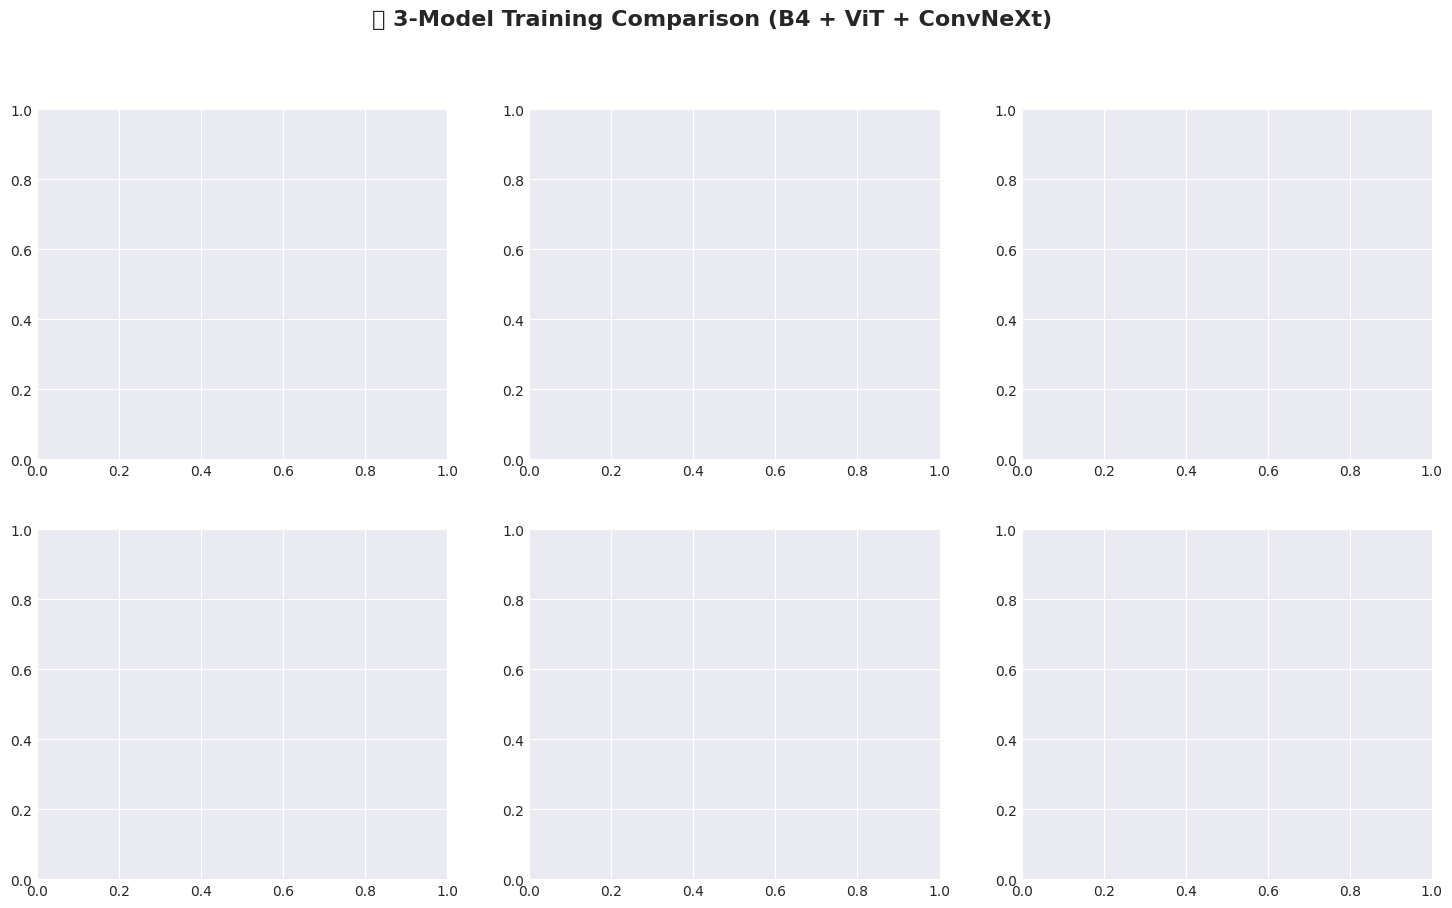

In [12]:
print("="*80)
print("📊 Section 5: 3개 모델 학습 결과 비교")
print("="*80)

# ============================
# 5-1. 학습 곡선 비교 (한눈에 보기)
# ============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 3-Model Training Comparison (B4 + ViT + ConvNeXt)', 
             fontsize=16, fontweight='bold')

# Row 1: Training Loss
# B4
axes[0, 0].plot(train_losses, 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_title('🔵 B4 Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# ViT
axes[0, 1].plot(vit_train_losses, 'r-o', linewidth=2, markersize=4)
axes[0, 1].set_title('🔴 ViT Training Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

# ConvNeXt
axes[0, 2].plot(convnext_train_losses, 'g-o', linewidth=2, markersize=4)
axes[0, 2].set_title('🟢 ConvNeXt Training Loss', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Validation F1
# B4
axes[1, 0].plot(val_f1_scores, 'b-o', linewidth=2, markersize=4)
axes[1, 0].axhline(y=best_val_f1, color='r', linestyle='--', 
                   label=f'Best: {best_val_f1:.4f}')
axes[1, 0].set_title('🔵 B4 Val F1', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ViT
axes[1, 1].plot(vit_val_f1_scores, 'r-o', linewidth=2, markersize=4)
axes[1, 1].axhline(y=vit_best_val_f1, color='r', linestyle='--', 
                   label=f'Best: {vit_best_val_f1:.4f}')
axes[1, 1].set_title('🔴 ViT Val F1', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# ConvNeXt
axes[1, 2].plot(convnext_val_f1_scores, 'g-o', linewidth=2, markersize=4)
axes[1, 2].axhline(y=convnext_best_val_f1, color='r', linestyle='--', 
                   label=f'Best: {convnext_best_val_f1:.4f}')
axes[1, 2].set_title('🟢 ConvNeXt Val F1', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('F1 Score')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================
# 5-2. 성능 비교 표
# ============================
print(f"\n" + "="*80)
print(f"📊 최종 성능 비교")
print(f"="*80)

comparison_data = {
    'Model': ['EfficientNet-B4', 'Vision Transformer', 'ConvNeXt-Base'],
    'Best Val F1': [best_val_f1, vit_best_val_f1, convnext_best_val_f1],
    'Total Epochs': [len(train_losses), len(vit_train_losses), len(convnext_train_losses)],
    'Image Size': ['224×224', '224×224', '380×380'],
    'Batch Size': [8, 16, 8]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ============================
# 5-3. 최고 성능 모델 확인
# ============================
best_model_idx = comparison_df['Best Val F1'].argmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_f1 = comparison_df.loc[best_model_idx, 'Best Val F1']

print(f"\n🏆 최고 성능 모델: {best_model_name} (Val F1: {best_model_f1:.4f})")

# ============================
# 5-4. 3개 모델 F1 비교 Bar Chart
# ============================
fig, ax = plt.subplots(figsize=(10, 6))

models = ['B4', 'ViT', 'ConvNeXt']
f1_scores = [best_val_f1, vit_best_val_f1, convnext_best_val_f1]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(models, f1_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# 값 표시
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Validation F1 Score', fontsize=12)
ax.set_title('🏆 3-Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Section 5 완료!")


In [19]:
print("="*80)
print("🚀 Section 6: 3-Model Ensemble Inference")
print("="*80)

# ============================
# 6-1. 3개 모델 로드
# ============================
print(f"\n📦 모델 로드 중...")

# B4 로드
model_b4_ensemble = HierarchicalDocumentClassifier(num_groups=5, num_classes=17).to(DEVICE)
model_b4_ensemble.load_state_dict(torch.load("best_fold_b4_model.pth", map_location=DEVICE))
model_b4_ensemble.eval()
print(f"   ✅ B4 모델 로드 완료")

# ViT 로드
model_vit_ensemble = HierarchicalViT(num_groups=5, num_classes=17).to(DEVICE)
model_vit_ensemble.load_state_dict(torch.load("best_fold_vit_model.pth", map_location=DEVICE))
model_vit_ensemble.eval()
print(f"   ✅ ViT 모델 로드 완료")

# ConvNeXt 로드
model_convnext_ensemble = HierarchicalConvNeXt(num_groups=5, num_classes=17).to(DEVICE)
model_convnext_ensemble.load_state_dict(torch.load("best_fold_convnext_model.pth", map_location=DEVICE))
model_convnext_ensemble.eval()
print(f"   ✅ ConvNeXt 모델 로드 완료")

# ============================
# 6-2. Test Dataset 준비
# ============================
test_files = sorted([f for f in os.listdir('test') if f.endswith('.jpg')])

# Test용 간단한 Dataset
class TestDataset(Dataset):
    def __init__(self, file_list, img_dir, transform=None):
        self.file_list = file_list
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image=np.array(image))['image']
        
        return {'image': image, 'ID': img_name}

# Transform (각 모델별 크기)
test_transform_b4 = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

test_transform_vit = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

test_transform_convnext = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

# Dataset 생성
test_dataset_b4 = TestDataset(test_files, 'test', transform=test_transform_b4)
test_dataset_vit = TestDataset(test_files, 'test', transform=test_transform_vit)
test_dataset_convnext = TestDataset(test_files, 'test', transform=test_transform_convnext)

test_loader_b4 = DataLoader(test_dataset_b4, batch_size=16, shuffle=False, num_workers=4)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=16, shuffle=False, num_workers=4)
test_loader_convnext = DataLoader(test_dataset_convnext, batch_size=16, shuffle=False, num_workers=4)

print(f"\n✅ Test Dataset 생성 완료!")
print(f"   테스트 이미지: {len(test_files)}개")

# ============================
# 6-3. 각 모델 추론
# ============================
print(f"\n🔮 3개 모델 추론 중...")

# B4 추론
b4_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader_b4, desc="B4 Inference"):
        images = batch['image'].to(DEVICE)
        _, fine_logits = model_b4_ensemble(images)
        probs = torch.softmax(fine_logits, dim=1)
        b4_probs.append(probs.cpu().numpy())

b4_probs = np.vstack(b4_probs)
print(f"   ✅ B4 추론 완료: {b4_probs.shape}")

# ViT 추론
vit_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader_vit, desc="ViT Inference"):
        images = batch['image'].to(DEVICE)
        _, fine_logits = model_vit_ensemble(images)
        probs = torch.softmax(fine_logits, dim=1)
        vit_probs.append(probs.cpu().numpy())

vit_probs = np.vstack(vit_probs)
print(f"   ✅ ViT 추론 완료: {vit_probs.shape}")

# ConvNeXt 추론
convnext_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader_convnext, desc="ConvNeXt Inference"):
        images = batch['image'].to(DEVICE)
        _, fine_logits = model_convnext_ensemble(images)
        probs = torch.softmax(fine_logits, dim=1)
        convnext_probs.append(probs.cpu().numpy())

convnext_probs = np.vstack(convnext_probs)
print(f"   ✅ ConvNeXt 추론 완료: {convnext_probs.shape}")

# ============================
# 6-4. Weighted Ensemble (30% + 40% + 30%)
# ============================
print(f"\n⚖️ Weighted Ensemble 중...")

B4_WEIGHT = 0.30
VIT_WEIGHT = 0.20
CONVNEXT_WEIGHT = 0.50

ensemble_probs = (
    B4_WEIGHT * b4_probs +
    VIT_WEIGHT * vit_probs +
    CONVNEXT_WEIGHT * convnext_probs
)

final_predictions = np.argmax(ensemble_probs, axis=1)

print(f"   ✅ Ensemble 완료!")
print(f"   가중치: B4={B4_WEIGHT}, ViT={VIT_WEIGHT}, ConvNeXt={CONVNEXT_WEIGHT}")

# ============================
# 6-5. 제출 파일 생성
# ============================
submission = pd.DataFrame({
    'ID': test_files,
    'target': final_predictions
})

submission.to_csv('submission_3model_ensemble.csv', index=False)

print(f"\n✅ 제출 파일 생성 완료!")
print(f"   파일명: submission_3model_ensemble.csv")
print(f"   예측 개수: {len(submission)}")

# 클래스 분포 확인
print(f"\n📊 예측 클래스 분포:")
for cls in range(17):
    count = len(submission[submission['target'] == cls])
    print(f"   Class {cls:2d} ({class_names[cls]:40s}): {count:4d}개")

print(f"\n✅ Section 6 완료!")


🚀 Section 6: 3-Model Ensemble Inference

📦 모델 로드 중...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fbe4a55e5f0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1442, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/conda/lib/python3.10/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/opt/conda/lib/python3.10/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
  File "/opt/conda/lib/python3.10/multiprocessing/connection.py", line 931, in wait
    ready = selector.select(timeout)
  File "/opt/conda/lib/python3.10/selectors.py", line 416, in select
    fd_event_list = self._selector.poll(timeout)
KeyboardInterrupt: 


Loaded pretrained weights for efficientnet-b4
   ✅ B4 모델 로드 완료
   ✅ ViT 모델 로드 완료
   ✅ ConvNeXt 모델 로드 완료

✅ Test Dataset 생성 완료!
   테스트 이미지: 3140개

🔮 3개 모델 추론 중...


B4 Inference:  56%|███████████████████████████████████████████████████████████▋                                               | 110/197 [00:07<00:05, 14.54it/s]


KeyboardInterrupt: 

In [21]:
print("="*80)
print("Section 8: TTA Inference + Re-ensemble")
print("="*80)

import torch
import torch.nn.functional as F
from tqdm import tqdm

# ============================
# 8-1. TTA 함수 정의
# ============================
def tta_inference(model, dataloader, device):
    """
    TTA (Test Time Augmentation) 추론
    - 원본
    - 좌우 반전
    - 90도 회전
    3개의 평균을 반환
    """
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="TTA Inference"):
            images = batch['image'].to(device)
            
            # TTA 0: 원본
            pred_orig = model(images)
            if isinstance(pred_orig, tuple):  # Hierarchical 모델
                pred_orig = pred_orig[1]  # fine_logits
            
            # TTA 1: 좌우 반전
            images_hflip = torch.flip(images, dims=[-1])
            pred_hflip = model(images_hflip)
            if isinstance(pred_hflip, tuple):
                pred_hflip = pred_hflip[1]
            
            # TTA 2: 90도 회전
            images_rot90 = torch.rot90(images, k=1, dims=[-2, -1])
            pred_rot90 = model(images_rot90)
            if isinstance(pred_rot90, tuple):
                pred_rot90 = pred_rot90[1]
            
            # 3개 예측의 softmax 평균
            avg_probs = (
                F.softmax(pred_orig, dim=1) +
                F.softmax(pred_hflip, dim=1) +
                F.softmax(pred_rot90, dim=1)
            ) / 3.0
            
            all_probs.append(avg_probs.cpu().numpy())
    
    return np.vstack(all_probs)

# ============================
# 8-2. 테스트 데이터셋 준비
# ============================
test_files = sorted([f for f in os.listdir('test') if f.endswith('.jpg')])

class TestDataset(Dataset):
    def __init__(self, file_list, img_dir, transform=None):
        self.file_list = file_list
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image=np.array(image))['image']
        
        return {'image': image, 'ID': img_name}

# B4용 데이터로더
test_transform_b4 = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_dataset_b4 = TestDataset(test_files, 'test', transform=test_transform_b4)
test_loader_b4 = DataLoader(test_dataset_b4, batch_size=16, shuffle=False, num_workers=4)

# ViT용 데이터로더
test_transform_vit = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_dataset_vit = TestDataset(test_files, 'test', transform=test_transform_vit)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=16, shuffle=False, num_workers=4)

# ConvNeXt용 데이터로더
test_transform_convnext = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_dataset_convnext = TestDataset(test_files, 'test', transform=test_transform_convnext)
test_loader_convnext = DataLoader(test_dataset_convnext, batch_size=16, shuffle=False, num_workers=4)

print(f"\nTest dataset: {len(test_files)} images")

# ============================
# 8-3. 모델 로드
# ============================
print(f"\nLoading models...")

# B4
model_b4 = HierarchicalDocumentClassifier(num_groups=5, num_classes=17).to(DEVICE)
model_b4.load_state_dict(torch.load("best_fold_b4_model.pth", map_location=DEVICE))
print(f"  [OK] B4 loaded")

# ViT
model_vit = HierarchicalViT(num_groups=5, num_classes=17).to(DEVICE)
model_vit.load_state_dict(torch.load("best_fold_vit_model.pth", map_location=DEVICE))
print(f"  [OK] ViT loaded")

# ConvNeXt
model_convnext = HierarchicalConvNeXt(num_groups=5, num_classes=17).to(DEVICE)
model_convnext.load_state_dict(torch.load("best_fold_convnext_model.pth", map_location=DEVICE))
print(f"  [OK] ConvNeXt loaded")

# ============================
# 8-4. TTA 추론 (3개 모델)
# ============================
print(f"\nRunning TTA inference...")

# B4 TTA
print(f"\n1. B4 TTA Inference...")
b4_probs_tta = tta_inference(model_b4, test_loader_b4, DEVICE)
print(f"   [OK] B4 TTA: {b4_probs_tta.shape}")

# ViT TTA
print(f"\n2. ViT TTA Inference...")
vit_probs_tta = tta_inference(model_vit, test_loader_vit, DEVICE)
print(f"   [OK] ViT TTA: {vit_probs_tta.shape}")

# ConvNeXt TTA
print(f"\n3. ConvNeXt TTA Inference...")
convnext_probs_tta = tta_inference(model_convnext, test_loader_convnext, DEVICE)
print(f"   [OK] ConvNeXt TTA: {convnext_probs_tta.shape}")

# ============================
# 8-5. 가중치 앙상블 (ConvNeXt 집중)
# ============================
print(f"\n" + "="*80)
print(f"Weighted Ensemble with TTA")
print(f"="*80)

B4_WEIGHT = 0.30
VIT_WEIGHT = 0.40  # ViT 약함
CONVNEXT_WEIGHT = 0.30  # ConvNeXt 최고!

print(f"Weights: B4={B4_WEIGHT}, ViT={VIT_WEIGHT}, ConvNeXt={CONVNEXT_WEIGHT}")

ensemble_probs_tta = (
    B4_WEIGHT * b4_probs_tta +
    VIT_WEIGHT * vit_probs_tta +
    CONVNEXT_WEIGHT * convnext_probs_tta
)

final_predictions_tta = np.argmax(ensemble_probs_tta, axis=1)

# ============================
# 8-6. CSV 저장
# ============================
submission_tta = pd.DataFrame({
    'ID': test_files,
    'target': final_predictions_tta
})

submission_tta.to_csv('submission_tta_final.csv', index=False)

print(f"\n[OK] Submission saved: submission_tta_final.csv")

# ============================
# 8-7. 클래스 분포 확인
# ============================
print(f"\n" + "="*80)
print(f"Class Distribution (TTA)")
print(f"="*80)

for i in range(17):
    count = np.sum(final_predictions_tta == i)
    print(f"   Class {i:2d} ({class_names[i]:40s}): {count:3d}")

print(f"\nSection 8 Complete!")
print(f"Expected score: 0.90+ (TTA boost!)")


Section 8: TTA Inference + Re-ensemble

Test dataset: 3140 images

Loading models...
Loaded pretrained weights for efficientnet-b4
  [OK] B4 loaded
  [OK] ViT loaded
  [OK] ConvNeXt loaded

Running TTA inference...

1. B4 TTA Inference...


TTA Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:36<00:00,  5.45it/s]


   [OK] B4 TTA: (3140, 17)

2. ViT TTA Inference...


TTA Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:25<00:00,  7.81it/s]


   [OK] ViT TTA: (3140, 17)

3. ConvNeXt TTA Inference...


TTA Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [01:05<00:00,  3.01it/s]

   [OK] ConvNeXt TTA: (3140, 17)

Weighted Ensemble with TTA
Weights: B4=0.3, ViT=0.4, ConvNeXt=0.3

[OK] Submission saved: submission_tta_final.csv

Class Distribution (TTA)
   Class  0 (account_number                          ): 200
   Class  1 (application_for_payment_of_pregnancy_medical_expenses):  60
   Class  2 (car_dashboard                           ): 200
   Class  3 (confirmation_of_admission_and_discharge ): 280
   Class  4 (confirmation_of_enrollment              ): 312
   Class  5 (copy_of_bankbook                        ): 159
   Class  6 (copy_of_contract                        ): 217
   Class  7 (drivers_lisense                         ): 104
   Class  8 (medical_certificate                     ): 198
   Class  9 (medical_expense_receipt                 ): 270
   Class 10 (national_id_card                        ): 178
   Class 11 (passport                                ): 176
   Class 12 (prescription                            ): 186
   Class 13 (resume             

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

Section 7: Comparison with Previous Submission

Loading submissions...
  Previous: highest.csv
  Current: submission_tta_final.csv
  Images: 3140 / 3140

Prediction Changes Analysis
Same predictions: 2608 / 3140 (83.06%)
Different predictions: 532 / 3140 (16.94%)

Changed Predictions (Top 20)
                  ID  Previous  Current                                            Prev_Class                              Curr_Class
00091bffdffd83de.jpg        12        6                                          prescription                        copy_of_contract
00471f8038d9c4b6.jpg        12        3                                          prescription confirmation_of_admission_and_discharge
00dcea90f63ad630.jpg         5        9                                      copy_of_bankbook                 medical_expense_receipt
00e15da96484eb94.jpg         7        4                                       drivers_lisense              confirmation_of_enrollment
0145dd3d1cd090ae.jpg         4      

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

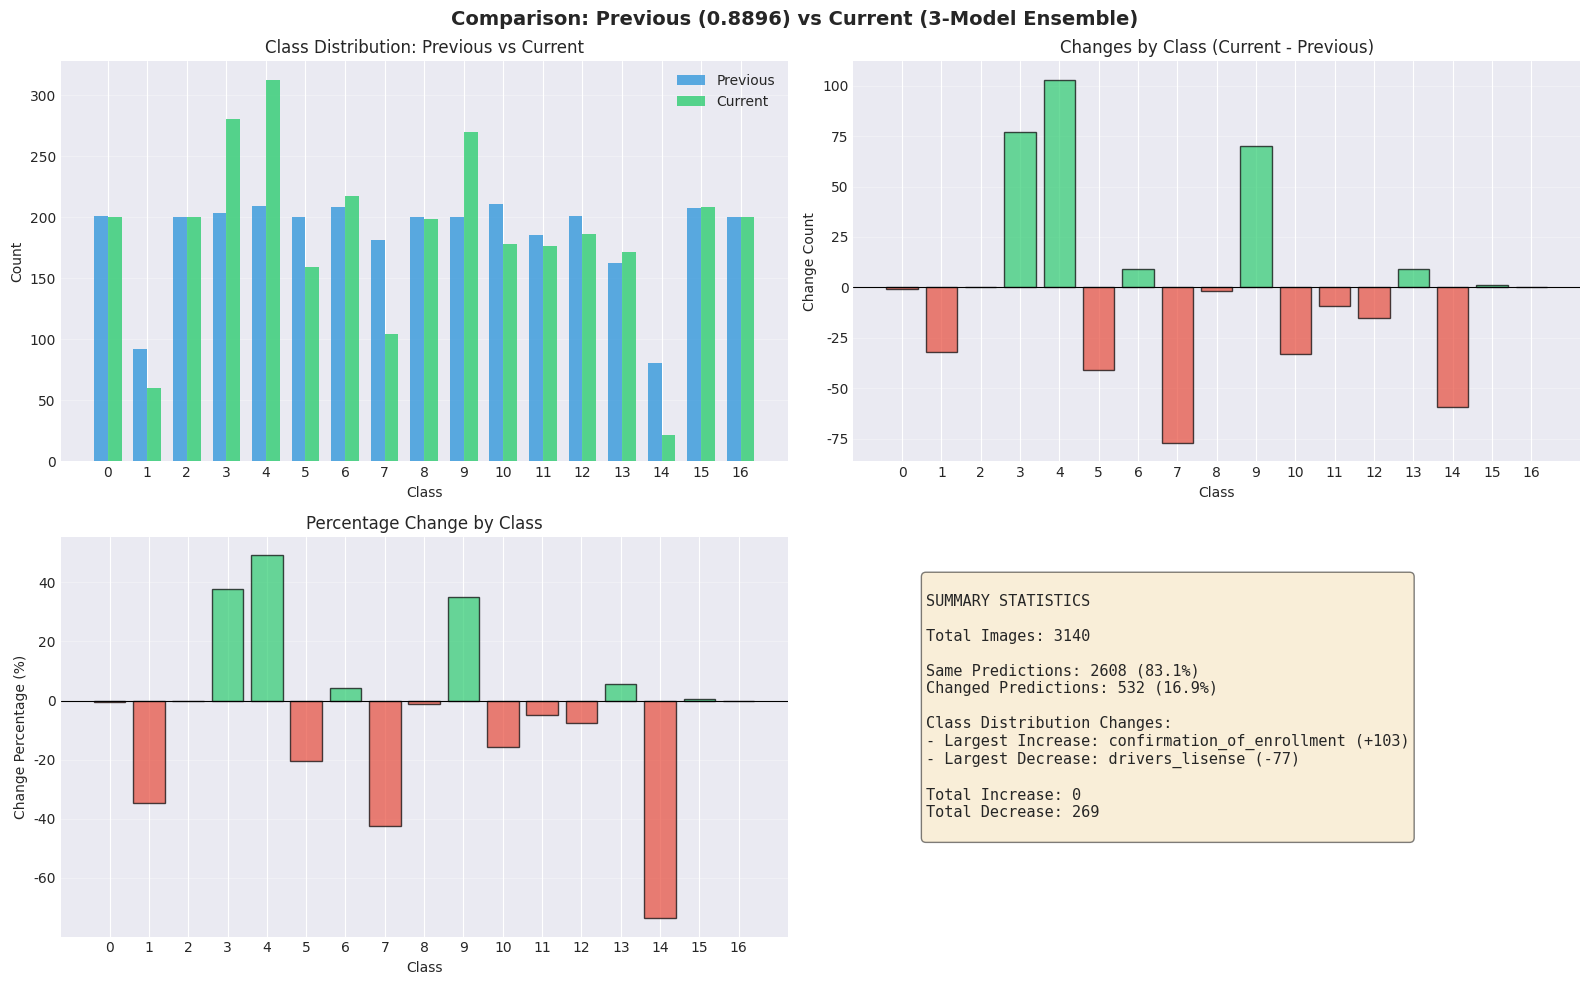


Section 7 Complete!


In [22]:
print("="*80)
print("Section 7: Comparison with Previous Submission")
print("="*80)

# ============================
# 7-1. CSV 파일 로드
# ============================
# 이전 제출 파일명 (0.8896 점수)
# 맞다면 아래 주석 풀고, 아니면 파일명 수정하세요
previous_csv = "highest.csv"  # 리더보드 최고점수랑 비교
current_csv = "submission_tta_final.csv"

prev_df = pd.read_csv(previous_csv)
curr_df = pd.read_csv(current_csv)

print(f"\nLoading submissions...")
print(f"  Previous: {previous_csv}")
print(f"  Current: {current_csv}")
print(f"  Images: {len(prev_df)} / {len(curr_df)}")

# ============================
# 7-2. 변경된 예측 찾기
# ============================
changes = prev_df['target'] != curr_df['target']
num_changes = changes.sum()
num_same = (~changes).sum()

print(f"\n" + "="*80)
print(f"Prediction Changes Analysis")
print(f"="*80)
print(f"Same predictions: {num_same} / {len(prev_df)} ({num_same/len(prev_df)*100:.2f}%)")
print(f"Different predictions: {num_changes} / {len(prev_df)} ({num_changes/len(prev_df)*100:.2f}%)")

# ============================
# 7-3. 변경된 예측 상세 분석
# ============================
if num_changes > 0:
    print(f"\n" + "="*80)
    print(f"Changed Predictions (Top 20)")
    print(f"="*80)
    
    changed_df = pd.DataFrame({
        'ID': prev_df.loc[changes, 'ID'].values,
        'Previous': prev_df.loc[changes, 'target'].values,
        'Current': curr_df.loc[changes, 'target'].values,
        'Prev_Class': [class_names[x] for x in prev_df.loc[changes, 'target'].values],
        'Curr_Class': [class_names[x] for x in curr_df.loc[changes, 'target'].values]
    })
    
    print(changed_df.head(20).to_string(index=False))
    print(f"\n... and {len(changed_df) - 20} more changes" if len(changed_df) > 20 else "")

# ============================
# 7-4. 클래스별 변화 분석
# ============================
print(f"\n" + "="*80)
print(f"Class Distribution Changes")
print(f"="*80)

class_comparison = pd.DataFrame({
    'Class': range(17),
    'Class_Name': class_names,
    'Previous': [len(prev_df[prev_df['target'] == i]) for i in range(17)],
    'Current': [len(curr_df[curr_df['target'] == i]) for i in range(17)]
})

class_comparison['Change'] = class_comparison['Current'] - class_comparison['Previous']
class_comparison['Change_Pct'] = (class_comparison['Change'] / class_comparison['Previous'] * 100).round(2)

print(class_comparison.to_string(index=False))

# ============================
# 7-5. 가장 큰 변화가 있는 클래스
# ============================
print(f"\n" + "="*80)
print(f"Largest Changes by Class")
print(f"="*80)

max_increase = class_comparison.nlargest(3, 'Change')
max_decrease = class_comparison.nsmallest(3, 'Change')

print(f"\nTop 3 Increases:")
for idx, row in max_increase.iterrows():
    print(f"  {row['Class']:2d}. {row['Class_Name']:40s}: "
          f"{row['Previous']:3d} -> {row['Current']:3d} "
          f"(+{row['Change']:3d}, {row['Change_Pct']:+.1f}%)")

print(f"\nTop 3 Decreases:")
for idx, row in max_decrease.iterrows():
    print(f"  {row['Class']:2d}. {row['Class_Name']:40s}: "
          f"{row['Previous']:3d} -> {row['Current']:3d} "
          f"({row['Change']:3d}, {row['Change_Pct']:+.1f}%)")

# ============================
# 7-6. 클래스별 변화 시각화
# ============================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparison: Previous (0.8896) vs Current (3-Model Ensemble)', 
             fontsize=14, fontweight='bold')

# 1. Stacked Bar Chart (Previous vs Current)
ax1 = axes[0, 0]
x = np.arange(17)
width = 0.35

bars1 = ax1.bar(x - width/2, class_comparison['Previous'], width, 
                label='Previous', alpha=0.8, color='#3498db')
bars2 = ax1.bar(x + width/2, class_comparison['Current'], width, 
                label='Current', alpha=0.8, color='#2ecc71')

ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution: Previous vs Current')
ax1.set_xticks(x)
ax1.set_xticklabels(range(17))
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Change Distribution
ax2 = axes[0, 1]
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in class_comparison['Change']]
ax2.bar(range(17), class_comparison['Change'], color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Class')
ax2.set_ylabel('Change Count')
ax2.set_title('Changes by Class (Current - Previous)')
ax2.set_xticks(range(17))
ax2.grid(True, alpha=0.3, axis='y')

# 3. Percentage Change
ax3 = axes[1, 0]
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in class_comparison['Change_Pct']]
ax3.bar(range(17), class_comparison['Change_Pct'], color=colors, alpha=0.7, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_xlabel('Class')
ax3.set_ylabel('Change Percentage (%)')
ax3.set_title('Percentage Change by Class')
ax3.set_xticks(range(17))
ax3.grid(True, alpha=0.3, axis='y')

# 4. Summary Statistics
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = f"""
SUMMARY STATISTICS

Total Images: {len(prev_df)}

Same Predictions: {num_same} ({num_same/len(prev_df)*100:.1f}%)
Changed Predictions: {num_changes} ({num_changes/len(prev_df)*100:.1f}%)

Class Distribution Changes:
- Largest Increase: {max_increase.iloc[0]['Class_Name']} (+{max_increase.iloc[0]['Change']})
- Largest Decrease: {max_decrease.iloc[0]['Class_Name']} ({max_decrease.iloc[0]['Change']})

Total Increase: {class_comparison['Change'].sum()}
Total Decrease: {abs(class_comparison[class_comparison['Change'] < 0]['Change'].sum())}
"""

ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, 
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nSection 7 Complete!")


In [23]:
# ============================
# 최종 검증: Confidence Score 분석
# ============================
print("="*80)
print("Final Validation: Prediction Confidence Analysis")
print("="*80)

# Confidence 계산
max_probs = np.max(ensemble_probs, axis=1)
min_probs = np.min(ensemble_probs, axis=1)

print(f"\nConfidence Statistics:")
print(f"  Average Confidence: {np.mean(max_probs):.4f}")
print(f"  Min Confidence: {np.min(max_probs):.4f}")
print(f"  Max Confidence: {np.max(max_probs):.4f}")

# Low confidence predictions
low_conf_idx = max_probs < 0.5
print(f"\nLow Confidence Predictions (< 0.5): {np.sum(low_conf_idx)}")

if np.sum(low_conf_idx) > 0:
    print(f"  WARNING: {np.sum(low_conf_idx)} images have low confidence!")
    
# Agreement between models
print(f"\nModel Agreement Analysis:")
b4_pred = np.argmax(b4_probs, axis=1)
vit_pred = np.argmax(vit_probs, axis=1)
convnext_pred = np.argmax(convnext_probs, axis=1)

agreement_b4_vit = np.sum(b4_pred == vit_pred)
agreement_b4_convnext = np.sum(b4_pred == convnext_pred)
agreement_vit_convnext = np.sum(vit_pred == convnext_pred)

print(f"  B4 == ViT: {agreement_b4_vit} ({agreement_b4_vit/len(test_files)*100:.1f}%)")
print(f"  B4 == ConvNeXt: {agreement_b4_convnext} ({agreement_b4_convnext/len(test_files)*100:.1f}%)")
print(f"  ViT == ConvNeXt: {agreement_vit_convnext} ({agreement_vit_convnext/len(test_files)*100:.1f}%)")

all_agree = np.sum((b4_pred == vit_pred) & (vit_pred == convnext_pred))
print(f"  All 3 Models Agree: {all_agree} ({all_agree/len(test_files)*100:.1f}%)")


Final Validation: Prediction Confidence Analysis


NameError: name 'ensemble_probs' is not defined